In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset .csv', encoding='latin-1')
df.head()

In [5]:
# Shape
print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (9551, 21)
['ï»¿Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [6]:
# Missing values
print(df.isnull().sum())

ï»¿Restaurant ID        0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [7]:
# Handle missing values
df['Cuisines'] = df['Cuisines'].fillna('Not Specified')

In [8]:
# Check data types
print(df.dtypes)

ï»¿Restaurant ID          int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object


count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


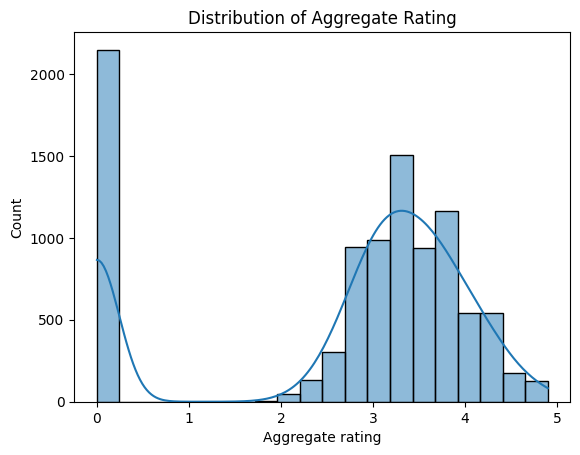

In [9]:
# Target variable distribution
print(df['Aggregate rating'].describe())
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title('Distribution of Aggregate Rating')
plt.show()

level1 :task 2

In [10]:
# Basic stats for numerical columns
df.describe()

,ï»¿Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [11]:
# Distribution of categorical variables
print(df['Country Code'].value_counts().head(10))
print(df['City'].value_counts().head(10))
print(df['Cuisines'].value_counts().head(10))

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64
Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [12]:
# Top cuisines by restaurant count
top_cuisines = df['Cuisines'].value_counts().head(10)
print(top_cuisines)

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [13]:
# Top cities by restaurant count
top_cities = df['City'].value_counts().head(10)
print(top_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


LEVEL 1 : TASK 3

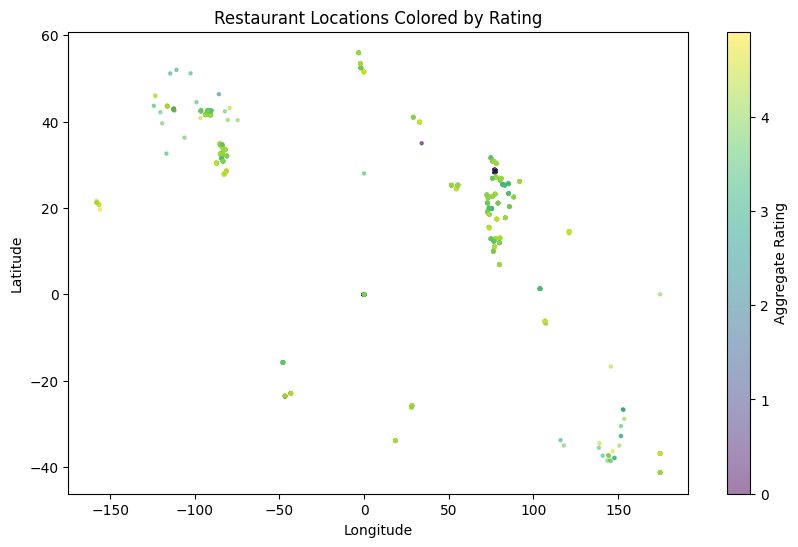

In [14]:
# Visualize restaurant locations on a map
plt.figure(figsize=(10,6))
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.5, c=df['Aggregate rating'], cmap='viridis')
plt.colorbar(label='Aggregate Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Restaurant Locations Colored by Rating')
plt.show()

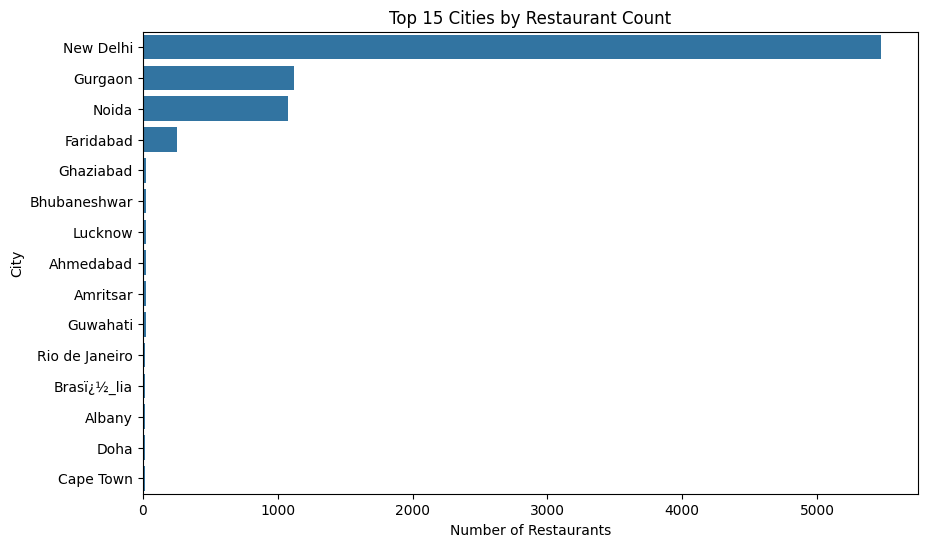

In [15]:
# Distribution across cities/countries
city_counts = df['City'].value_counts().head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.xlabel('Number of Restaurants')
plt.title('Top 15 Cities by Restaurant Count')
plt.show()

In [16]:
# Correlation between location and rating
# Simple approach: correlation of lat/long with rating
print(df[['Latitude', 'Longitude', 'Aggregate rating']].corr())

                  Latitude  Longitude  Aggregate rating
Latitude          1.000000   0.043207          0.000516
Longitude         0.043207   1.000000         -0.116818
Aggregate rating  0.000516  -0.116818          1.000000


In [17]:
# Optional: interactive map with folium (nicer for showcasing in your video/LinkedIn post)
!pip install folium -q
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=2)
marker_cluster = MarkerCluster().add_to(m)

# Sample 500 points so it doesn't crash the browser
sample = df.sample(500, random_state=1)
for _, row in sample.iterrows():
    folium.Marker([row['Latitude'], row['Longitude']],
                   popup=row['Restaurant Name']).add_to(marker_cluster)
m